# MSME Churn Prediction — Data Preparation
## Loading, anonymising, cleaning, and encoding the raw logistics dataset

Raw data: 9,581 shipment records from Tata nexarc internship (July 2024)  
PII removed: customer names, contacts, emails, GST numbers, addresses  
Output: Clean encoded dataset ready for EDA and modelling

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [34]:
df = pd.read_excel('Data/July Data Analysis.xlsx', sheet_name='Raw Sheet')

In [36]:
print("Shape:", df.shape)
print("Columns:")
for col in df.columns:
    print(" -", col)

Shape: (9581, 89)
Columns:
 - Transaction ID
 - Shipment ID
 - Customer name
 - Customer contact
 - Customer e-mail
 - UTN
 - Business ID
 - Legal name
 - Billing GSTIN
 - Billing pincode
 - Billing city
 - Business Name
 - Consignor name
 - Consignor contact
 - Consignor e-mail
 - Consignor address
 - LSP name
 - Recommended LSP
 - Pickup ID
 - Tracking ID
 - Consignee name
 - Consignee contact
 - Consignee e-mail
 - Consignee address
 - Shipment booking date and time
 - Pickup request generated
 - Pickup request generated date and time
 - Scheduled pick up date
 - Expected pickup date
 - Actual pickup date
 - TAT
 - Scheduled delivery date
 - Expected delivery date
 - Destination arrival date
 - Actual delivery date
 - Pickup delay
 - Pickup delay reason
 - Pickup delay sub-reason
 - Total delay
 - Delivery delay reason
 - Delivery delay sub-reason
 - From pincode
 - To pincode
 - From City
 - To City
 - No. of boxes
 - Total Actual Weight (kg)
 - Charged Weight
 - LSP-Charged Weight

## Step 1 — Anonymisation
Dropping all personally identifiable information before any analysis.
22 columns removed including customer names, contacts, GST numbers, and addresses.

In [37]:
# Drop all PII columns
pii_columns = ['Customer name', 'Customer contact', 'Customer e-mail',
    'Legal name', 'Billing GSTIN', 'Billing pincode', 'Billing city',
    'Business Name', 'Consignor name', 'Consignor contact', 'Consignor e-mail',
    'Consignor address', 'Consignee name', 'Consignee contact', 'Consignee e-mail',
    'Consignee address', 'Goods Invoice No.', 'Eway Bill No.',
    'Freight invoice no.', 'Payment ID', 'Tracking ID', 'Pickup ID']
df_clean = df.drop(columns=pii_columns)

In [38]:
print("Original shape:", df.shape)
print("Anonymized shape:", df_clean.shape)
print("Columns removed:", len(pii_columns))

Original shape: (9581, 89)
Anonymized shape: (9581, 67)
Columns removed: 22


In [39]:
print("Retained Next Month - value counts:")
print(df_clean['Retained Next Month'].value_counts(dropna=False))

print("\nAs Percentage:")
print(df_clean['Retained Next Month'].value_counts(normalize=True, dropna=False).round(3)*100)

Retained Next Month - value counts:
Retained Next Month
NaN      3658
0.0      2467
1.0       467
2.0       377
6.0       229
4.0       193
3.0       150
7.0       127
5.0       115
8.0       115
30.0      109
10.0      102
58.0      101
109.0      93
12.0       92
101.0      77
44.0       76
13.0       76
16.0       68
9.0        64
11.0       61
34.0       55
56.0       55
17.0       52
18.0       51
46.0       51
42.0       48
77.0       46
41.0       44
48.0       44
25.0       41
51.0       39
19.0       35
39.0       34
43.0       30
15.0       22
14.0       20
26.0       19
63.0       18
23.0       18
24.0       17
35.0       16
93.0        9
Name: count, dtype: int64

As Percentage:
Retained Next Month
NaN      38.2
0.0      25.7
1.0       4.9
2.0       3.9
6.0       2.4
4.0       2.0
3.0       1.6
7.0       1.3
5.0       1.2
8.0       1.2
30.0      1.1
10.0      1.1
58.0      1.1
109.0     1.0
12.0      1.0
101.0     0.8
44.0      0.8
13.0      0.8
16.0      0.7
9.0       0.7


In [40]:
# Drop rows where Retained Next Month is unknown (NaN)
# These are customers where we don't have next month data yet
df_model = df_clean.dropna(subset=['Retained Next Month'])

# Convert to binary: 0 stays 0 (churned), anything above 0 becomes 1 (retained)
df_model['churned'] = (df_model['Retained Next Month'] == 0).astype(int)
# astype(int) converts True/False to 1/0
# True means they DID churn, so churned = 1

print("Rows after dropping NaN:", len(df_model))
print("\nChurn distribution:")
print(df_model['churned'].value_counts())
print("\nAs percentages:")
print((df_model['churned'].value_counts(normalize=True) * 100).round(1))

Rows after dropping NaN: 5923

Churn distribution:
churned
0    3456
1    2467
Name: count, dtype: int64

As percentages:
churned
0    58.3
1    41.7
Name: proportion, dtype: float64


## Step 2 — Feature Selection and Null Analysis
Selecting operationally relevant features for churn prediction.
Checking for missing values before cleaning.

In [41]:
# Look at the columns we care about for prediction
feature_cols = [
    'LSP name', 'Overall SLA Compliance', 'Pick Up Compliance',
    'Customer Order sequence', 'Key Accounts', 
    'Customer Status for the month', 'Total Delay Days',
    'Pick up delay Days', 'Net Revenue', 'Total Actual Weight (kg)',
    'Total goods Invoice Value'
]

# Check how many nulls exist in each of these columns
print("Null counts in feature columns:")
print(df_model[feature_cols].isnull().sum())

print("\nData types:")
print(df_model[feature_cols].dtypes)

Null counts in feature columns:
LSP name                         435
Overall SLA Compliance           148
Pick Up Compliance               148
Customer Order sequence            0
Key Accounts                       0
Customer Status for the month      0
Total Delay Days                 145
Pick up delay Days               145
Net Revenue                        1
Total Actual Weight (kg)           0
Total goods Invoice Value          0
dtype: int64

Data types:
LSP name                          object
Overall SLA Compliance            object
Pick Up Compliance                object
Customer Order sequence          float64
Key Accounts                      object
Customer Status for the month     object
Total Delay Days                  object
Pick up delay Days                object
Net Revenue                      float64
Total Actual Weight (kg)         float64
Total goods Invoice Value        float64
dtype: object


In [42]:
# Make a copy so we don't mess up df_model
df_features = df_model[feature_cols + ['churned']].copy()

# Fix delay columns — convert text to numeric
# errors='coerce' means if it can't convert, make it NaN instead of crashing
df_features['Total Delay Days'] = pd.to_numeric(df_features['Total Delay Days'], errors='coerce')
df_features['Pick up delay Days'] = pd.to_numeric(df_features['Pick up delay Days'], errors='coerce')

# Fill nulls in numeric columns with 0
# Delay being null likely means no delay, so 0 is appropriate
numeric_cols = ['Total Delay Days', 'Pick up delay Days', 'Net Revenue']
df_features[numeric_cols] = df_features[numeric_cols].fillna(0)

# Fill nulls in LSP name with 'Unknown'
df_features['LSP name'] = df_features['LSP name'].fillna('Unknown')

# Fill nulls in SLA columns with 'Unknown'
df_features['Overall SLA Compliance'] = df_features['Overall SLA Compliance'].fillna('Unknown')
df_features['Pick Up Compliance'] = df_features['Pick Up Compliance'].fillna('Unknown')

# Verify no nulls remain
print("Null counts after cleaning:")
print(df_features.isnull().sum())

Null counts after cleaning:
LSP name                         0
Overall SLA Compliance           0
Pick Up Compliance               0
Customer Order sequence          0
Key Accounts                     0
Customer Status for the month    0
Total Delay Days                 0
Pick up delay Days               0
Net Revenue                      0
Total Actual Weight (kg)         0
Total goods Invoice Value        0
churned                          0
dtype: int64


In [43]:
# Check what's actually in each categorical column
for col in categorical_cols:
    types = df_features[col].apply(type).value_counts()
    print(f"\n{col}:")
    print(types)
    print("Sample values:", df_features[col].unique()[:5])


LSP name:
LSP name
<class 'str'>    5923
Name: count, dtype: int64
Sample values: ['GATI' 'DELHIVERY' 'SCORPION' 'OXYZEN' 'V-XPRESS']

Overall SLA Compliance:
Overall SLA Compliance
<class 'int'>    5696
<class 'str'>     227
Name: count, dtype: int64
Sample values: [1 0 'Unknown' '\xa0']

Pick Up Compliance:
Pick Up Compliance
<class 'int'>    5696
<class 'str'>     227
Name: count, dtype: int64
Sample values: [0 1 'Unknown' '\xa0']

Key Accounts:
Key Accounts
<class 'str'>    5923
Name: count, dtype: int64
Sample values: ['Non Key Account' 'Key Account']

Customer Status for the month:
Customer Status for the month
<class 'str'>    5905
<class 'int'>      18
Name: count, dtype: int64
Sample values: ['-' 'Retained' 'Re-activated' 'NCA' 0]


## Step 3 — Cleaning and Encoding
Converting mixed types to clean strings, handling Excel whitespace artifacts,
mapping SLA columns to readable labels, then label encoding all categorical variables.
Label mappings saved to JSON for reference during modelling and visualisation.

In [44]:
# Convert all categorical columns to clean strings before encoding
# This forces everything to be the same type
# str(x).strip() converts to string and removes any whitespace

for col in categorical_cols:
    df_features[col] = df_features[col].apply(lambda x: str(x).strip())

# Verify all are now clean strings
for col in categorical_cols:
    types = df_features[col].apply(type).value_counts()
    print(f"{col}: {types.to_dict()}")
    print("Sample values:", df_features[col].unique()[:5])
    print()

LSP name: {<class 'str'>: 5923}
Sample values: ['GATI' 'DELHIVERY' 'SCORPION' 'OXYZEN' 'V-XPRESS']

Overall SLA Compliance: {<class 'str'>: 5923}
Sample values: ['1' '0' 'Unknown' '']

Pick Up Compliance: {<class 'str'>: 5923}
Sample values: ['0' '1' 'Unknown' '']

Key Accounts: {<class 'str'>: 5923}
Sample values: ['Non Key Account' 'Key Account']

Customer Status for the month: {<class 'str'>: 5923}
Sample values: ['-' 'Retained' 'Re-activated' 'NCA' '0']



In [45]:
# Re-pull LSP name from df_model since it got encoded earlier
df_features['LSP name'] = df_model['LSP name'].fillna('Unknown').apply(lambda x: str(x).strip())

# Replace empty strings with 'Unknown' in SLA columns
df_features['Overall SLA Compliance'] = df_features['Overall SLA Compliance'].replace('', 'Unknown')
df_features['Pick Up Compliance'] = df_features['Pick Up Compliance'].replace('', 'Unknown')

# Verify
for col in categorical_cols:
    print(f"{col}: {df_features[col].unique()[:6]}")

LSP name: ['GATI' 'DELHIVERY' 'SCORPION' 'OXYZEN' 'V-XPRESS' 'V-TRANS']
Overall SLA Compliance: ['1' '0' 'Unknown']
Pick Up Compliance: ['0' '1' 'Unknown']
Key Accounts: ['Non Key Account' 'Key Account']
Customer Status for the month: ['-' 'Retained' 'Re-activated' 'NCA' '0']


In [46]:
# Map SLA columns explicitly
sla_map = {'1': 'Compliant', '0': 'Non-Compliant', 'Unknown': 'Unknown'}
df_features['Overall SLA Compliance'] = df_features['Overall SLA Compliance'].map(sla_map)
df_features['Pick Up Compliance'] = df_features['Pick Up Compliance'].map(sla_map)

# Clean up Customer Status
df_features['Customer Status for the month'] = df_features['Customer Status for the month'].replace({
    '0': 'Unknown',
    '-': 'Unknown'
})

# Verify
for col in categorical_cols:
    print(f"{col}: {df_features[col].unique()}")

LSP name: ['GATI' 'DELHIVERY' 'SCORPION' 'OXYZEN' 'V-XPRESS' 'V-TRANS' 'Unknown']
Overall SLA Compliance: ['Compliant' 'Non-Compliant' 'Unknown']
Pick Up Compliance: ['Non-Compliant' 'Compliant' 'Unknown']
Key Accounts: ['Non Key Account' 'Key Account']
Customer Status for the month: ['Unknown' 'Retained' 'Re-activated' 'NCA']


In [47]:
# Now encode all categorical columns cleanly
le = LabelEncoder()

# Store the mappings so we can interpret results later
label_mappings = {}

for col in categorical_cols:
    df_features[col] = le.fit_transform(df_features[col])
    # Save mapping: number -> original label
    label_mappings[col] = dict(zip(le.transform(le.classes_), le.classes_))
    print(f"{col}: {label_mappings[col]}")

LSP name: {np.int64(0): 'DELHIVERY', np.int64(1): 'GATI', np.int64(2): 'OXYZEN', np.int64(3): 'SCORPION', np.int64(4): 'Unknown', np.int64(5): 'V-TRANS', np.int64(6): 'V-XPRESS'}
Overall SLA Compliance: {np.int64(0): 'Compliant', np.int64(1): 'Non-Compliant', np.int64(2): 'Unknown'}
Pick Up Compliance: {np.int64(0): 'Compliant', np.int64(1): 'Non-Compliant', np.int64(2): 'Unknown'}
Key Accounts: {np.int64(0): 'Key Account', np.int64(1): 'Non Key Account'}
Customer Status for the month: {np.int64(0): 'NCA', np.int64(1): 'Re-activated', np.int64(2): 'Retained', np.int64(3): 'Unknown'}


In [48]:
# Final check before modelling
print("Shape:", df_features.shape)
print("\nNull counts:")
print(df_features.isnull().sum())
print("\nFirst 3 rows:")
print(df_features.head(3))
print("\nChurn distribution:")
print(df_features['churned'].value_counts())

Shape: (5923, 12)

Null counts:
LSP name                         0
Overall SLA Compliance           0
Pick Up Compliance               0
Customer Order sequence          0
Key Accounts                     0
Customer Status for the month    0
Total Delay Days                 0
Pick up delay Days               0
Net Revenue                      0
Total Actual Weight (kg)         0
Total goods Invoice Value        0
churned                          0
dtype: int64

First 3 rows:
   LSP name  Overall SLA Compliance  Pick Up Compliance  \
0         1                       0                   1   
1         1                       0                   0   
2         1                       0                   0   

   Customer Order sequence  Key Accounts  Customer Status for the month  \
0                      1.0             1                              3   
1                      1.0             1                              3   
2                      1.0             1                  

In [52]:
df_features.to_csv('Data/msme_churn_clean.csv', index=False)

with open('Data/label_mappings.json', 'w') as f:
    clean_mappings = {
        col: {int(k): v for k, v in mapping.items()}
        for col, mapping in label_mappings.items()
    }
    json.dump(clean_mappings, f, indent=2)

print("Saved:")
print("- msme_churn_clean.csv")
print("- label_mappings.json")

Saved:
- msme_churn_clean.csv
- label_mappings.json


In [53]:
#DAY 2
df = pd.read_csv('data/msme_churn_clean.csv')
print(df.shape)

(5923, 12)


In [54]:
# Set visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load label mappings so we can use original names in charts
import json
with open('data/label_mappings.json', 'r') as f:
    label_mappings = json.load(f)

print("Style set, mappings loaded")

Style set, mappings loaded


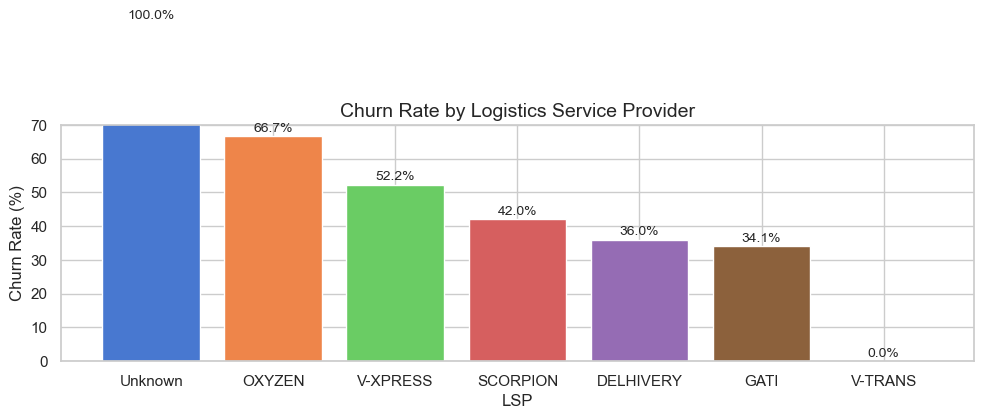

Saved to outputs/


In [56]:
# Chart 1 — Churn rate by LSP
# Map numbers back to original LSP names
df['LSP label'] = df['LSP name'].astype(str).map(label_mappings['LSP name'])

# Calculate churn rate per LSP
lsp_churn = df.groupby('LSP label')['churned'].mean().sort_values(ascending=False).reset_index()
lsp_churn['churn_pct'] = (lsp_churn['churned'] * 100).round(1)

# Plot
fig, ax = plt.subplots()
bars = ax.bar(lsp_churn['LSP label'], lsp_churn['churn_pct'], color=sns.color_palette('muted'))

# Add value labels on top of each bar
for bar, val in zip(bars, lsp_churn['churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Churn Rate by Logistics Service Provider')
ax.set_xlabel('LSP')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig('Outputs/churn_by_lsp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

In [57]:
print(df[df['LSP name'] == 5]['churned'].value_counts())
# 5 = V-TRANS from our label mappings

churned
0    1
Name: count, dtype: int64


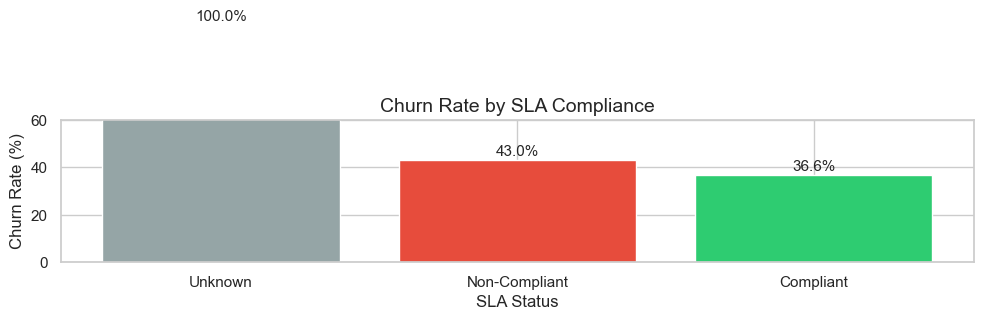

Saved to outputs/


In [58]:
# Chart 2 — Churn rate by SLA Compliance
df['SLA label'] = df['Overall SLA Compliance'].astype(str).map(label_mappings['Overall SLA Compliance'])

sla_churn = df.groupby('SLA label')['churned'].mean().sort_values(ascending=False).reset_index()
sla_churn['churn_pct'] = (sla_churn['churned'] * 100).round(1)

fig, ax = plt.subplots()
colors = ['#e74c3c' if x == 'Non-Compliant' else '#2ecc71' if x == 'Compliant' else '#95a5a6' 
          for x in sla_churn['SLA label']]
bars = ax.bar(sla_churn['SLA label'], sla_churn['churn_pct'], color=colors)

for bar, val in zip(bars, sla_churn['churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Churn Rate by SLA Compliance')
ax.set_xlabel('SLA Status')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('outputs/churn_by_sla.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

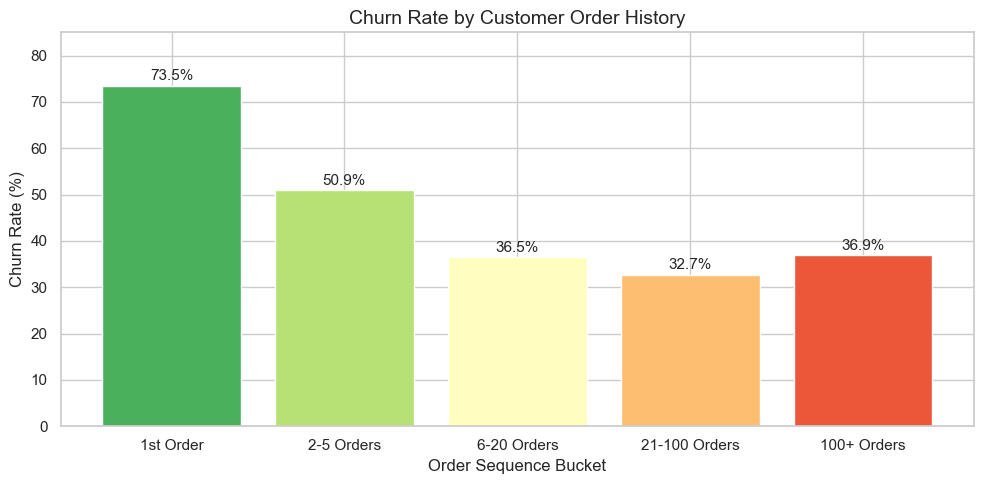

Saved to outputs/


In [59]:
# Chart 3 — Churn rate by order sequence bucket
# Bucket customers by how many orders they've placed
df['order_bucket'] = pd.cut(
    df['Customer Order sequence'],
    bins=[0, 1, 5, 20, 100, 10000],
    labels=['1st Order', '2-5 Orders', '6-20 Orders', '21-100 Orders', '100+ Orders']
)

order_churn = df.groupby('order_bucket', observed=True)['churned'].mean().reset_index()
order_churn['churn_pct'] = (order_churn['churned'] * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(order_churn['order_bucket'], order_churn['churn_pct'],
              color=sns.color_palette('RdYlGn_r', len(order_churn)))

for bar, val in zip(bars, order_churn['churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Churn Rate by Customer Order History')
ax.set_xlabel('Order Sequence Bucket')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 85)
plt.tight_layout()
plt.savefig('outputs/churn_by_order_sequence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

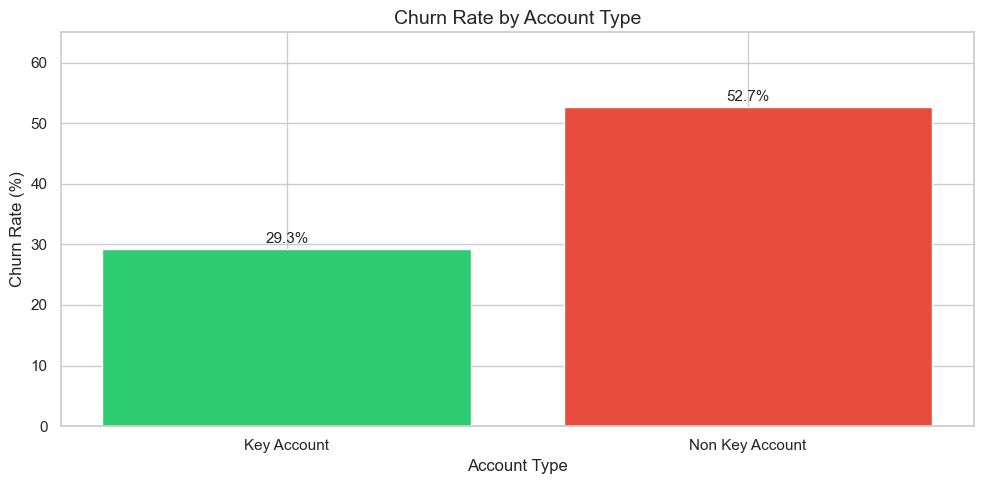

Saved to outputs/


In [60]:
# Chart 4 — Churn rate by key account status
df['KA label'] = df['Key Accounts'].astype(str).map(label_mappings['Key Accounts'])

ka_churn = df.groupby('KA label')['churned'].mean().reset_index()
ka_churn['churn_pct'] = (ka_churn['churned'] * 100).round(1)

fig, ax = plt.subplots()
colors = ['#2ecc71' if x == 'Key Account' else '#e74c3c' for x in ka_churn['KA label']]
bars = ax.bar(ka_churn['KA label'], ka_churn['churn_pct'], color=colors)

for bar, val in zip(bars, ka_churn['churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Churn Rate by Account Type')
ax.set_xlabel('Account Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 65)
plt.tight_layout()
plt.savefig('outputs/churn_by_key_account.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## Key EDA Findings

| Signal | Finding |
|---|---|
| First-order customers | 73.5% churn rate — dominant predictor |
| Key Account vs Non-Key | 29.3% vs 52.7% churn — nearly double |
| SLA Non-Compliance | 43.0% churn vs 36.6% compliant |
| V-XPRESS | 52.2% churn — worst performing LSP |
| GATI | 34.1% churn — best performing LSP |
| Unknown LSP/SLA | 100% churn — missing data = operational failure |

**Core insight:** If an MSME places only one order and is not a key account, 
churn risk is extremely high regardless of delivery performance. 
The critical intervention window is between order 1 and order 5.